ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
# Make plots look cleaner
sns.set()

Saving mission_launches.csv to mission_launches.csv


In [45]:
#Reading my dataset
df = pd.read_csv("mission_launches.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [46]:
#Checking dataset columns
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')


### Check Missing Values

In [47]:
#Check all values
print(df.isna())

      Unnamed: 0.1  Unnamed: 0  Organisation  Location   Date  Detail  \
0            False       False         False     False  False   False   
1            False       False         False     False  False   False   
2            False       False         False     False  False   False   
3            False       False         False     False  False   False   
4            False       False         False     False  False   False   
...            ...         ...           ...       ...    ...     ...   
4319         False       False         False     False  False   False   
4320         False       False         False     False  False   False   
4321         False       False         False     False  False   False   
4322         False       False         False     False  False   False   
4323         False       False         False     False  False   False   

      Rocket_Status  Price  Mission_Status  
0             False  False           False  
1             False  False       

In [48]:
#Total of missing values
print(df.isna().sum())

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64


### Check duplicate rows

In [49]:
#checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


### No. of rows and columns

In [51]:
#finding number of rows and columns
print("Shape (rows, columns): ", df.shape,"\n")
print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (4324, 9) 

number of rows:  4324
number of columns:  9


### Data type of columns

In [52]:
#Checking datatypes of the columns
df.dtypes

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
Organisation,object
Location,object
Date,object
Detail,object
Rocket_Status,object
Price,object
Mission_Status,object


# Data Cleaning
After examining the data, several data cleaning steps are needed as shown below:

In [53]:
#To make all dates matching in style to enable date time analysis
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dtypes

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
Organisation,object
Location,object
Date,"datetime64[ns, UTC]"
Detail,object
Rocket_Status,object
Price,object
Mission_Status,object


In [54]:
#To see how many dates faild the conversion
df['Date'].isna().sum()

np.int64(126)

In [55]:
#Drop useless columns such as price
df = df.drop(columns=['Price'])
#Clean orgnisation by removing extra spaces
df['Organisation'] = df['Organisation'].str.strip()
#Create country column because it's needed for plotting
df['Country'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())
#extracted year column because it's needed for plotting
df['Year'] = df['Date'].dt.year

df.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status,Country,Year
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,Success,USA,2020.0
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,Success,China,2020.0
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,Success,USA,2020.0
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,Success,Kazakhstan,2020.0
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,Success,USA,2020.0


In [56]:
# Statistical summary
df.describe(include='all')

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Mission_Status,Country,Year
count,4324.000000,4324.000000,4324,4324,4198,4324,4324,4324,4324,4198.000000
unique,NaN,NaN,56,137,NaN,4278,2,4,22,NaN
top,NaN,NaN,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan",NaN,Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,Success,Russia,NaN
freq,NaN,NaN,1777,235,NaN,6,3534,3879,1395,NaN
mean,2161.500000,2161.500000,NaN,NaN,1987-12-23 12:59:23.639828416+00:00,NaN,NaN,NaN,NaN,1987.455693
min,0.000000,0.000000,NaN,NaN,1957-10-04 19:28:00+00:00,NaN,NaN,NaN,NaN,1957.000000
25%,1080.750000,1080.750000,NaN,NaN,1972-05-05 17:21:00+00:00,NaN,NaN,NaN,NaN,1972.000000
50%,2161.500000,2161.500000,NaN,NaN,1985-01-24 06:21:30+00:00,NaN,NaN,NaN,NaN,1985.000000
75%,3242.250000,3242.250000,NaN,NaN,2002-10-05 00:25:30+00:00,NaN,NaN,NaN,NaN,2002.000000
max,4323.000000,4323.000000,NaN,NaN,2020-08-07 05:12:00+00:00,NaN,NaN,NaN,NaN,2020.000000


## Data Visualization and insights
Created several visualizations in order to explore patterns, trends, etc..

### Univariate Analysis

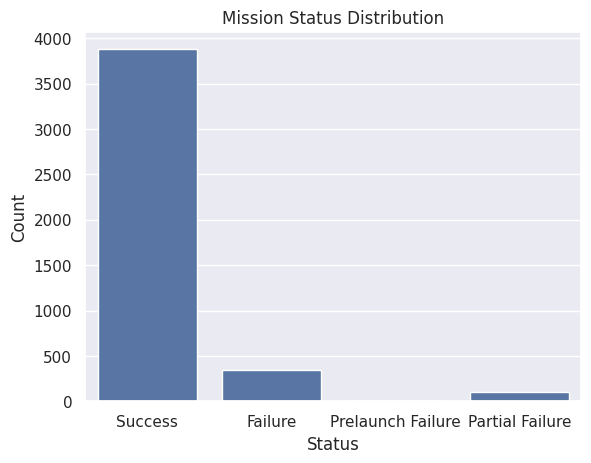

In [43]:
sns.countplot(data=df, x='Mission_Status')
plt.title("Mission Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

- Shows distribution of mission outcomes. This plot helps with understanding the results.
- Most missions are successful

### Distribution of Revenue

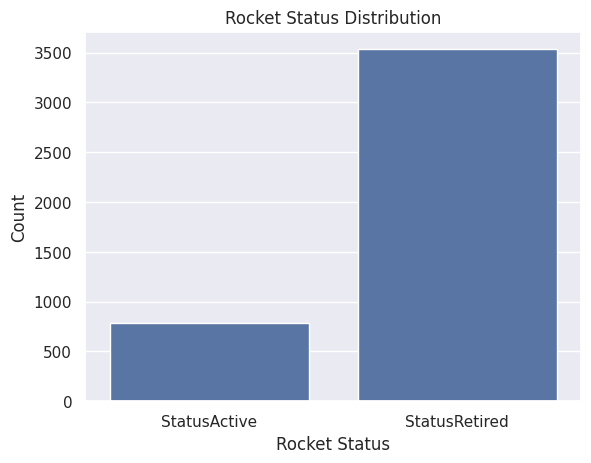

In [42]:
sns.countplot(data=df, x='Rocket_Status')
plt.title("Rocket Status Distribution")
plt.xlabel("Rocket Status")
plt.ylabel("Count")
plt.show()



*   Shows distribution of rocket status. This plot helps with understanding the results.
*   Most rockets are currently active.





## Bivariate Analysis

### Revenue by Country

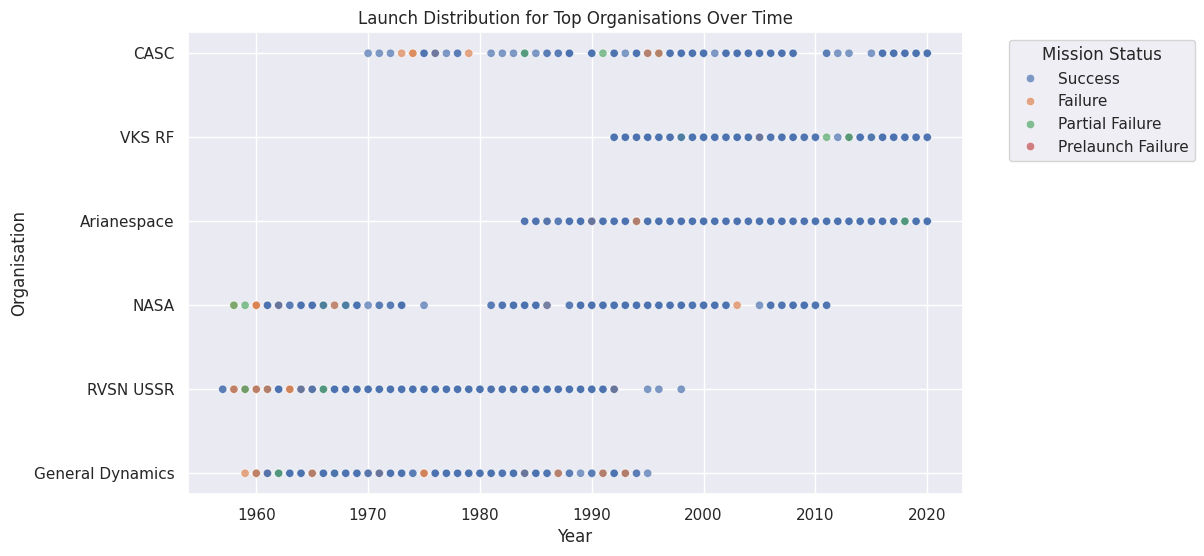

In [40]:
topOrgs = df['Organisation'].value_counts().head(6).index
filtered_df = df[df['Organisation'].isin(topOrgs)]
plt.figure(figsize=(10,6))
sns.scatterplot(data=filtered_df, x='Year', y='Organisation', hue='Mission_Status', alpha=0.7)
plt.title("Launch Distribution for Top Organisations Over Time")
plt.xlabel("Year")
plt.ylabel("Organisation")
plt.legend(title="Mission Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



*   Each point represents a year and the number of launches in that year. Scatter plots are amazing in visiualizing relationships.
*   It shows that VKS RF has the most successful launches relatively.



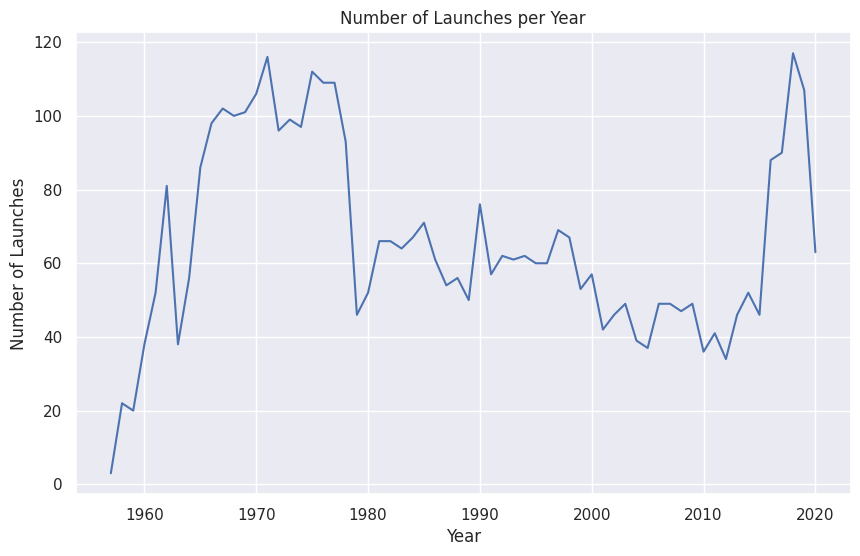

In [41]:
launchesPERyear = df['Year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
sns.lineplot(x=launchesPERyear.index, y=launchesPERyear.values)
plt.title("Number of Launches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.show()



*   This line plot shows the number of launches per year and orders them chronologically. It's useful to show changes over time.
*   Two peaks are showing: 1970-1973 and 2017-2018



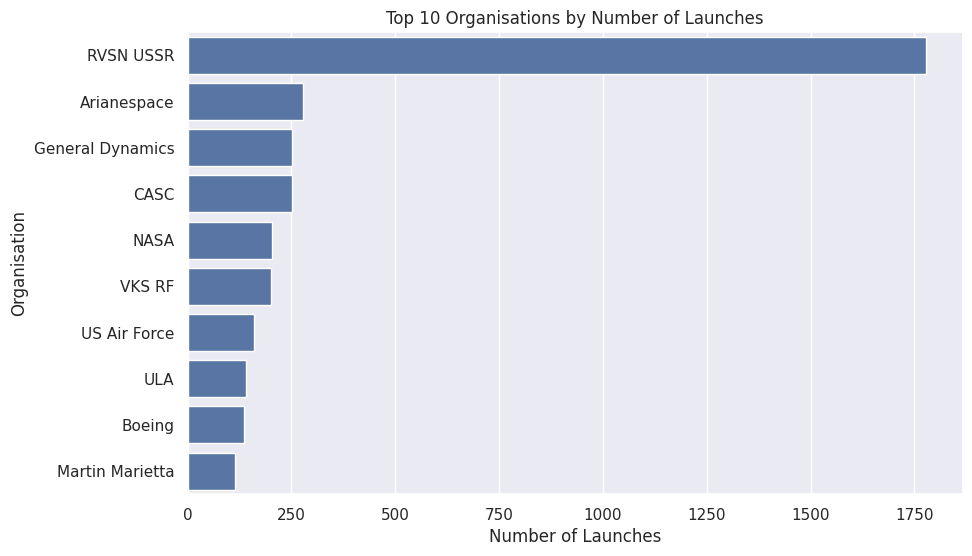

In [38]:
topOrgs = df['Organisation'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=topOrgs.values, y=topOrgs.index)
plt.title("Top 10 Organisations by Number of Launches")
plt.xlabel("Number of Launches")
plt.ylabel("Organisation")
plt.show()



*   This bar chart illustrates top 10 orgnization by the number of rockets launched. It's effective in comparing entities.
*   According to the chart, RVSN USSR is the leading orgnization with a number exceeding 1750.



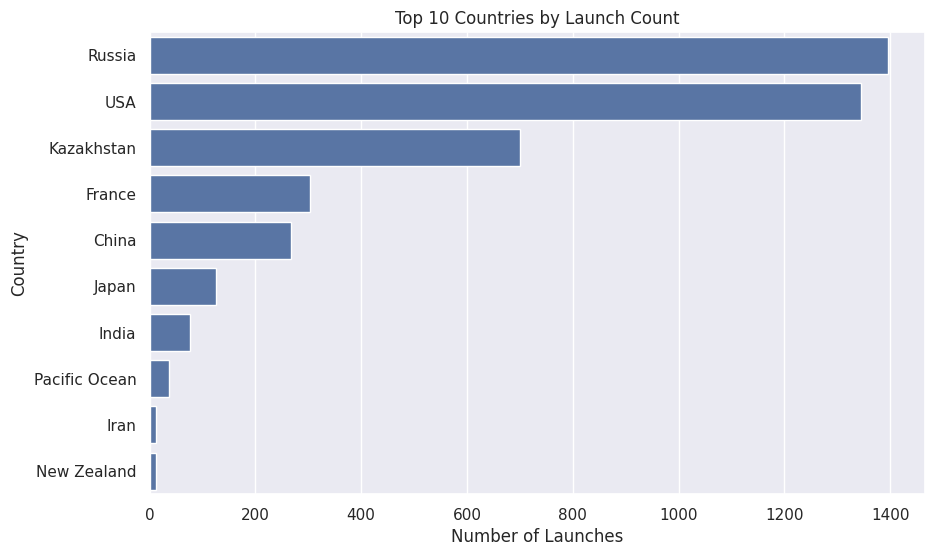

In [37]:
topCountries = df['Country'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=topCountries.values, y=topCountries.index)
plt.title("Top 10 Countries by Launch Count")
plt.xlabel("Number of Launches")
plt.ylabel("Country")
plt.show()


*   This bar chart illustrates top 10 cpuntries by the number of rockets launched. It's effective in comparing entities.
*   Clearly, Russia is leading out of all the countries with an approximation of 1400.



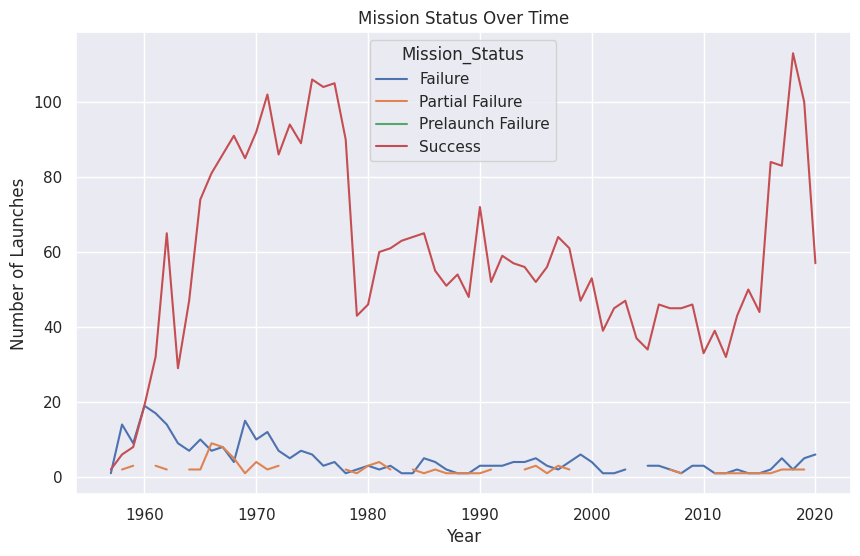

In [36]:
statusYear = df.groupby(['Year', 'Mission_Status']).size().unstack()
statusYear.plot(kind='line', figsize=(10,6))
plt.title("Mission Status Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.show()


*   This plot shows how many missions fall into each catagory ( failure, success, etc.. ). Count plots are best for catagorial distribution.
*   By looking at the graph, most missions were successful.



# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
